# Intraday SVR Momentum Query Backtest

This notebook fetches intraday `IRS_RATE` data for `USD-SOFR-1D-Q12STIRT` / `IMM_4xIMM_5`, builds
an SVR momentum signal (ported from the Matlab `pfBBGHourlySVM` intraday pipeline), runs a quick
vectorized sanity check, and then runs the canonical `QueryDrivenBacktest` implementation.

**Algorithm (Matlab intraday port):**
1. Long EMA − Short EMA cross-spreads, each individually min/max scaled to [-1, 1]
2. Intercept column prepended
3. 1-step-ahead returns as continuous target (also min/max scaled)
4. SVR (RBF kernel, C=400, γ=0.5) predicts next return; sign → position

**Key differences from the EOD PCA-SVM variant:**
- Regression (SVR) instead of classification (SVC)
- No PCA — features stay in original space
- Per-feature min/max scaling instead of global StandardScaler
- Cross-spreads only (no EMA−SMA pairs)

Data is resampled to 30-min bars to keep SVR training tractable.

In [29]:
%load_ext autoreload
%autoreload 2

import datetime
import sys

import matplotlib.pyplot as plt
import pandas as pd
import pytz

sys.path.append("../../")

from BT.signals import svr_momentum_signal, svr_momentum_signal_optimized , run_technical_indicator_query_backtest
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP
from Query.IRSwaps.IRSwapQuery import IRSwapQuery
from Query.IRSwaps.IRSwapValue import IRSwapValue
from Query.Unified.UnifiedQuery import UnifiedQuery
from Query.Unified.registry import UnifiedValue
from TB.TimeseriesBuilder import TimeseriesBuilder

NYC = pytz.timezone("America/New_York")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [59]:
curve_mdp = IRSwapsMDP(source="BARCHART_STIRF-RL")
ts_builder = TimeseriesBuilder()
trade_bpv = 100_000.0

start = NYC.localize(datetime.datetime(2026, 1, 3, 18, 0))
end = NYC.localize(datetime.datetime(2026, 3, 27, 17, 0))

q = UnifiedQuery(
    curve="USD-SOFR-1D-Q12STIRT",
    tenor="IMM_12xIMM_13",
    value=UnifiedValue.IRS_RATE,
)

intraday_df = ts_builder.get_timeseries(
    start=start,
    end=end,
    queries=[q],
    freq="15min",
    mdps={"IRS": curve_mdp},
    ignore_cache_miss=True,
)
intraday_df = intraday_df.sort_index()

rate_series = pd.to_numeric(intraday_df.iloc[:, 0], errors="coerce").dropna()
# Resample to 30-min bars for SVR tractability
# rate_series = rate_series.resample("30min").last().dropna()
rate_series.name = "IMM_4xIMM_5"

rate_series

Date
2026-01-04 18:00:00-05:00    3.479710
2026-01-04 18:15:00-05:00    3.472772
2026-01-04 18:30:00-05:00    3.477697
2026-01-04 18:45:00-05:00    3.474706
2026-01-04 19:00:00-05:00    3.474706
                               ...   
2026-03-27 16:00:00-04:00    3.608266
2026-03-27 16:15:00-04:00    3.603270
2026-03-27 16:30:00-04:00    3.611472
2026-03-27 16:45:00-04:00    3.611251
2026-03-27 17:00:00-04:00    3.613193
Name: IMM_4xIMM_5, Length: 5338, dtype: float64

In [60]:
# SVR Momentum signal — Matlab pfBBGHourlySVM intraday port
# Cross-spread windows for 30-min bars (~48 bars/day)
signal_result = svr_momentum_signal_optimized(
    rate_series,
    ewma_short_spans=[1, 6, 12, 24],   # Matlab: [24,48,120,240] hours → same in 30-min bars
    ewma_long_spans=[72, 120, 240],      # Matlab: [360,1080,1440] hours
    svr_c=400.0,                            # Matlab C=400
    svr_gamma=0.25,                          # Matlab gamma=0.5
    svr_epsilon=0.000000025,                # Matlab insensitivity
    signal_threshold=0.0,                   # sign of prediction → position
    train_fraction=0.6,                     # Matlab DataSplit=0.7
    retrain_every=48,                       # retrain daily (expanding window)
)

display(signal_result.indicator_frame.tail())
display(
    pd.DataFrame(
        {
            "rate": signal_result.raw_series,
            "desired_position": signal_result.desired_position,
            "execution_position": signal_result.execution_position,
        }
    ).tail()
)

Building SVR momentum signal...: 100%|██████████| 45/45 [00:00<00:00, 116.33block/s]


,predicted_return,scaled_target
Date,,
2026-03-27 16:00:00-04:00,0.000679,-0.004996
2026-03-27 16:15:00-04:00,0.000867,0.008202
2026-03-27 16:30:00-04:00,0.000493,-0.000222
2026-03-27 16:45:00-04:00,0.000489,0.001942
2026-03-27 17:00:00-04:00,NaN,NaN


,rate,desired_position,execution_position
Date,,,
2026-03-27 16:00:00-04:00,3.608266,1.0,1.0
2026-03-27 16:15:00-04:00,3.603270,1.0,1.0
2026-03-27 16:30:00-04:00,3.611472,1.0,1.0
2026-03-27 16:45:00-04:00,3.611251,1.0,1.0
2026-03-27 17:00:00-04:00,3.613193,NaN,1.0


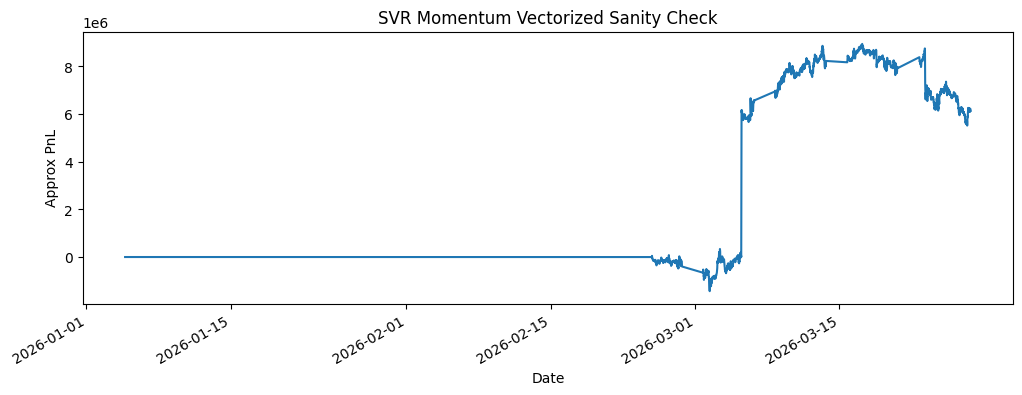

In [61]:
# Vectorized sanity check only. The canonical result is the query-driven backtest below.
vectorized_position = signal_result.execution_position.fillna(0.0)
vectorized_pnl = -vectorized_position * rate_series.diff().fillna(0.0) * trade_bpv * 100.0
vectorized_cumulative_pnl = vectorized_pnl.cumsum()

fig, ax = plt.subplots(figsize=(12, 4))
vectorized_cumulative_pnl.plot(ax=ax, title="SVR Momentum Vectorized Sanity Check")
ax.set_ylabel("Approx PnL")
plt.show()

In [62]:
# Keep timestamp="now" so the query-driven backtest requests true intraday curves.
def trade_query_factory(target_position, now, info):
    _ = now, info
    return IRSwapQuery(
        curve="USD-SOFR-1D-Q12STIRT",
        tenor="IMM_4xIMM_5",
        value=IRSwapValue.NPV,
        market_request={"timestamp": "now"},
        structure_kwargs={"bpv": trade_bpv * float(target_position)},
        tags=("intraday_svr_momentum_q12stirt",),
    )


query_backtest = run_technical_indicator_query_backtest(
    signal_result,
    trade_query_factory=trade_query_factory,
    mdp=curve_mdp,
    strategy_name="intraday_svr_momentum_q12stirt",
    ignore_cache_miss=True,
    show_progress=True,
)

query_backtest.metrics

INTRADAY_SVR_MOMENTUM_Q12STIRT QUERY BT: 100%|██████████| 5338/5338 [00:50<00:00, 105.16step/s] 


{'total_pnl': 7388137.9312755205,
 'sharpe': 2.27022071842756,
 'max_drawdown': -6748763.520840779,
 'trade_sides': 135.0}

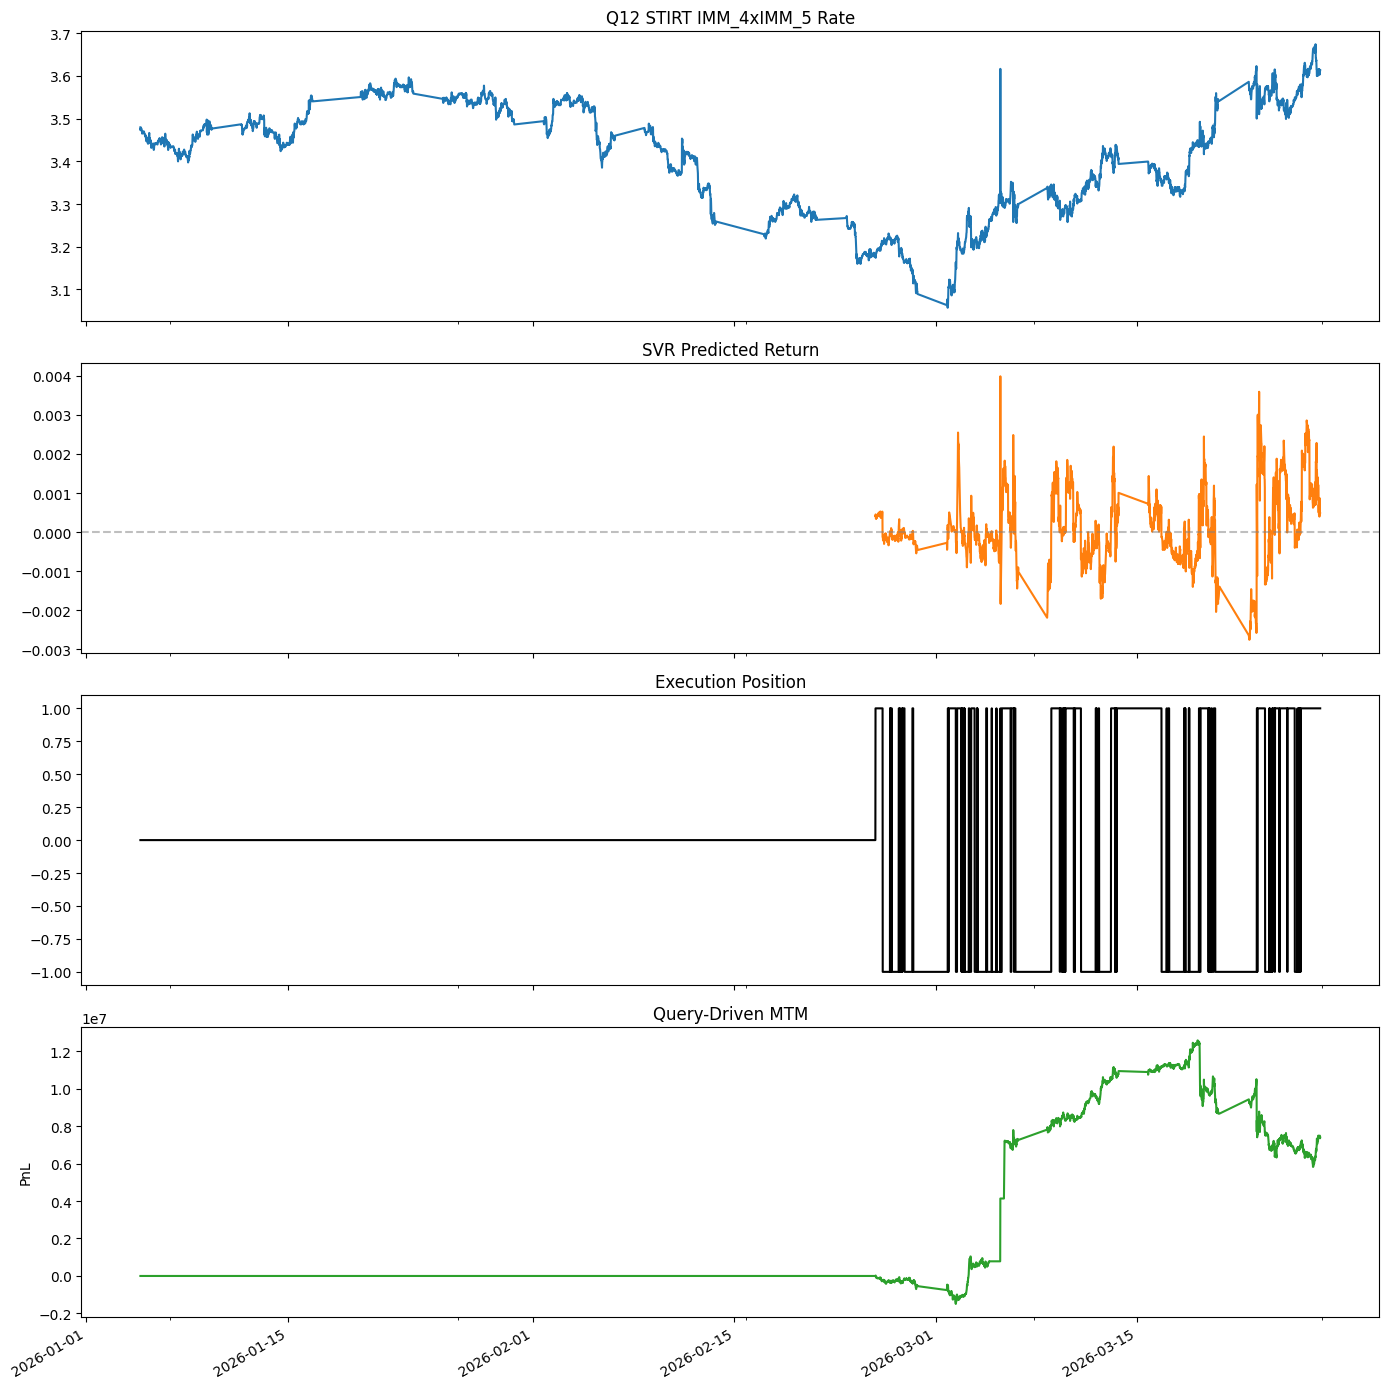

In [65]:
from BT.query_tearsheet import QueryBacktestTearSheet
tearsheet = QueryBacktestTearSheet.from_backtest(query_backtest.backtest)
tearsheet.plot_plotly().show()

plot_df = pd.DataFrame(
    {
        "rate": signal_result.raw_series,
        "predicted_return": signal_result.indicator_frame["predicted_return"],
        "execution_position": signal_result.execution_position,
    }
).dropna(subset=["rate"])

fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)
plot_df["rate"].plot(ax=axes[0], title="Q12 STIRT IMM_4xIMM_5 Rate")
plot_df["predicted_return"].dropna().plot(
    ax=axes[1], title="SVR Predicted Return", color="tab:orange",
)
axes[1].axhline(0, color="gray", linestyle="--", alpha=0.5)
plot_df["execution_position"].fillna(0.0).plot(
    ax=axes[2], title="Execution Position", color="black",
)
query_backtest.mtm_history.plot(
    ax=axes[3], title="Query-Driven MTM", color="tab:green",
)
axes[3].set_ylabel("PnL")
plt.tight_layout()
plt.show()

# query_backtest.order_frame.tail()